# Trial CLIP untuk Identifikasi Kata Benda Visual

Notebook ini membaca satu gambar, membuat caption visual otomatis, mengekstrak kata benda/objek dari caption tersebut, lalu memakai CLIP untuk memberi skor relevansi tiap kata benda terhadap gambar.

Catatan: CLIP bukan model generatif, jadi CLIP tidak bisa menulis label baru sendirian. Di notebook ini daftar kosa kata manual dihapus; kandidat kata benda dibuat dinamis dari caption gambar, kemudian CLIP dipakai untuk memvalidasi dan mengurutkannya.

## 1. Setup

Jika package belum tersedia, jalankan baris berikut sekali saja:

```python
# %pip install -q torch transformers pillow pandas
```

In [28]:
from pathlib import Path
import re

import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from transformers import (
    BlipForConditionalGeneration,
    BlipProcessor,
    CLIPModel,
    CLIPProcessor,
)

IMAGE_PATH = Path("dataset/images/71.jpg")
MODEL_NAME = "openai/clip-vit-base-patch32"
CAPTION_MODEL_NAME = "Salesforce/blip-image-captioning-base"

# CLIP sudah tersedia di cache lokal pada project ini.
CLIP_LOCAL_FILES_ONLY = True

# BLIP dipakai untuk membuat caption bebas; False agar otomatis download saat pertama kali dipakai.
CAPTION_LOCAL_FILES_ONLY = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_NOUN_CANDIDATES = 30
MAX_DETECTED_NOUNS = 15
MIN_PROBABILITY = 0.02

image_stem = IMAGE_PATH.stem
print(f"Device: {DEVICE}")
print(f"Image path: {IMAGE_PATH.resolve()}")

Device: cpu
Image path: C:\Users\elsae\.vscode\Documents\city-branding-multimodal\dataset\images\71.jpg


In [29]:
CAPTION_PROMPTS = [
    None,
    "a photo of",
    "the image shows",
    "visible objects include",
]

STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "have",
    "in", "into", "is", "it", "its", "near", "next", "of", "on", "or", "that", "the",
    "there", "this", "to", "with", "without",
}

VISUAL_STOPWORDS = {
    "background", "caption", "foreground", "image", "large", "little", "many", "old",
    "photo", "picture", "scene", "several", "small", "some", "view", "visible",
    "black", "blue", "brown", "gray", "green", "orange", "purple", "red", "white", "yellow",
    "standing", "sitting", "walking", "looking", "holding", "wearing",
}

SINGULAR_OVERRIDES = {
    "buildings": "building",
    "cars": "car",
    "clouds": "cloud",
    "houses": "house",
    "mountains": "mountain",
    "people": "person",
    "persons": "person",
    "plants": "plant",
    "roads": "road",
    "signs": "sign",
    "trees": "tree",
    "vehicles": "vehicle",
}


def normalize_candidate(text: str) -> str:
    text = re.sub(r"[^a-z0-9\s-]", " ", text.lower())
    words = []
    for word in text.split():
        word = SINGULAR_OVERRIDES.get(word, word)
        if len(word) < 3 or word in STOPWORDS or word in VISUAL_STOPWORDS:
            continue
        if word.endswith("ing") and word != "building":
            continue
        words.append(word)
    return " ".join(words).strip()


def unique_keep_order(items: list[str]) -> list[str]:
    seen = set()
    unique = []
    for item in items:
        if item and item not in seen:
            seen.add(item)
            unique.append(item)
    return unique


def extract_noun_candidates(captions: list[str], max_candidates: int = MAX_NOUN_CANDIDATES) -> list[str]:
    candidates = []
    for caption in captions:
        normalized_caption = re.sub(r"[^a-z0-9\s-]", " ", caption.lower())
        raw_words = normalized_caption.split()
        content_words = [normalize_candidate(word) for word in raw_words]
        content_words = [word for word in content_words if word]

        candidates.extend(content_words)
        for left, right in zip(content_words, content_words[1:]):
            if left != right:
                candidates.append(f"{left} {right}")

    return unique_keep_order(candidates)[:max_candidates]

In [30]:
try:
    processor = CLIPProcessor.from_pretrained(
        MODEL_NAME,
        local_files_only=CLIP_LOCAL_FILES_ONLY,
        use_fast=False,
    )
    model = CLIPModel.from_pretrained(
        MODEL_NAME,
        local_files_only=CLIP_LOCAL_FILES_ONLY,
    ).to(DEVICE)
    model.eval()
except OSError as exc:
    raise RuntimeError(
        "Model CLIP belum ada di cache lokal. Jika ingin download otomatis, ubah "
        "CLIP_LOCAL_FILES_ONLY = False lalu jalankan ulang cell ini dengan koneksi internet."
    ) from exc

try:
    caption_processor = BlipProcessor.from_pretrained(
        CAPTION_MODEL_NAME,
        local_files_only=CAPTION_LOCAL_FILES_ONLY,
    )
    caption_model = BlipForConditionalGeneration.from_pretrained(
        CAPTION_MODEL_NAME,
        local_files_only=CAPTION_LOCAL_FILES_ONLY,
    ).to(DEVICE)
    caption_model.eval()
except OSError as exc:
    raise RuntimeError(
        "Model captioning BLIP belum bisa dimuat. Pastikan koneksi internet tersedia untuk "
        "download pertama kali, atau ubah CAPTION_LOCAL_FILES_ONLY = True jika model sudah ada di cache."
    ) from exc

print("Model CLIP dan captioning siap dipakai.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model CLIP dan captioning siap dipakai.


Ukuran gambar: 1080 x 1350


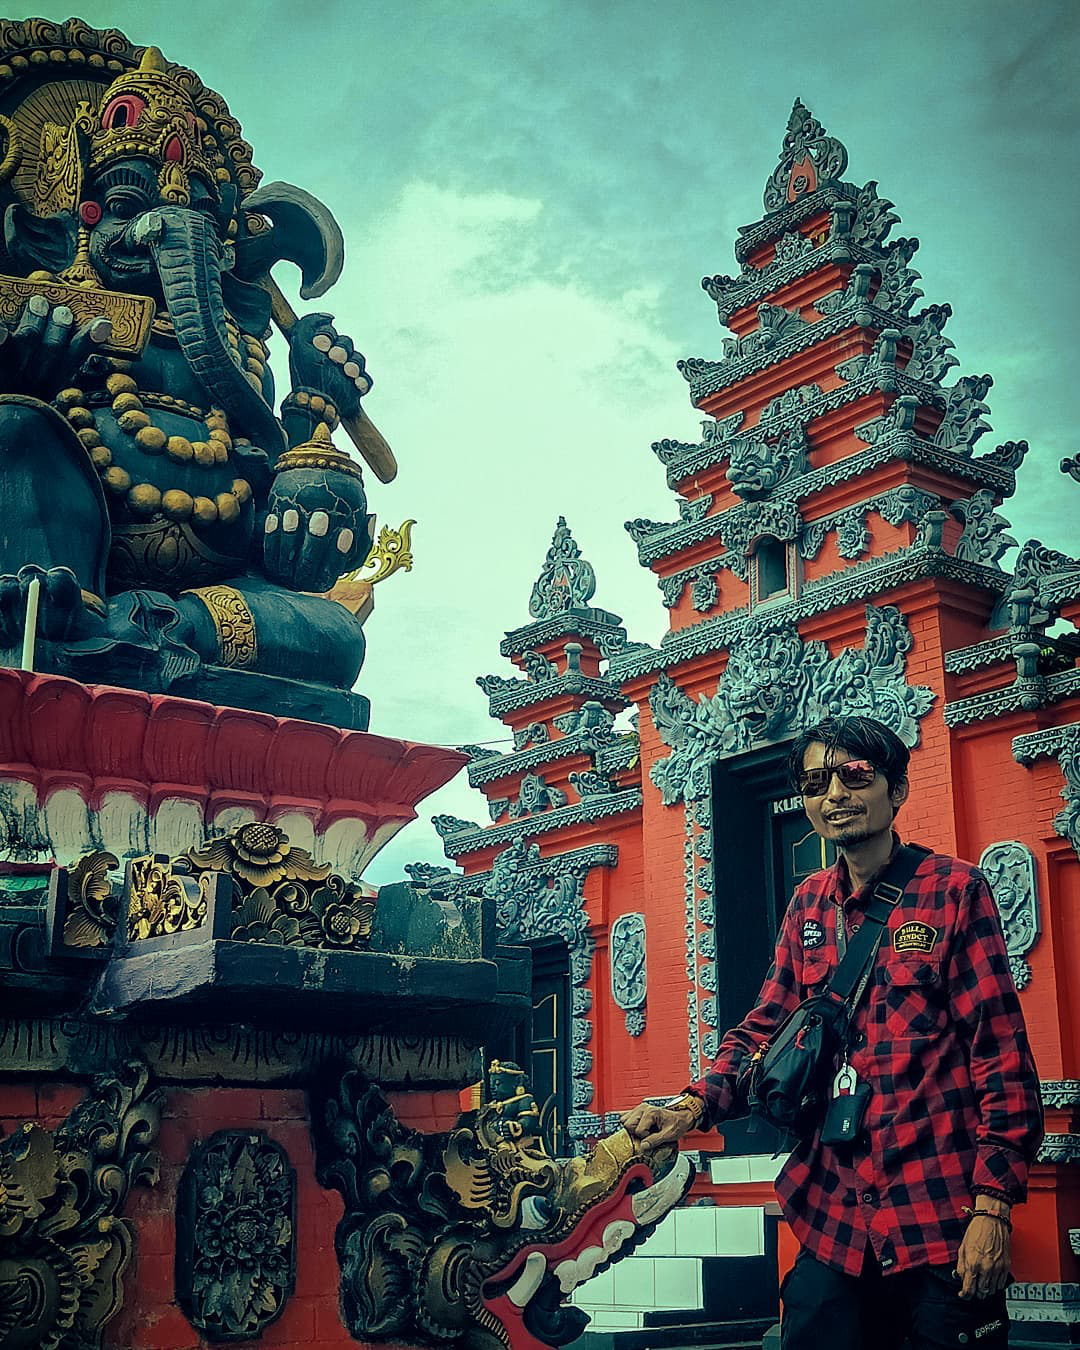

In [31]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Gambar tidak ditemukan: {IMAGE_PATH.resolve()}")

image = Image.open(IMAGE_PATH).convert("RGB")
print(f"Ukuran gambar: {image.size[0]} x {image.size[1]}")
display(image)

In [32]:
PROMPT_TEMPLATES = [
    "a photo of a {noun}",
    "a photo containing a {noun}",
    "the image shows a {noun}",
    "a visible {noun} in the image",
]


def make_prompts(noun: str) -> list[str]:
    return [template.format(noun=noun) for template in PROMPT_TEMPLATES]


def get_logits_per_image(outputs) -> torch.Tensor:
    if hasattr(outputs, "logits_per_image"):
        return outputs.logits_per_image
    if isinstance(outputs, dict) and "logits_per_image" in outputs:
        return outputs["logits_per_image"]
    if isinstance(outputs, (tuple, list)):
        return outputs[0]
    raise TypeError(f"Output CLIP tidak memiliki logits_per_image: {type(outputs)}")


@torch.no_grad()
def generate_image_captions(image_path: Path, prompts: list = CAPTION_PROMPTS) -> list[str]:
    image = Image.open(image_path).convert("RGB")
    captions = []

    for prompt in prompts:
        processor_kwargs = {"images": image, "return_tensors": "pt"}
        if prompt:
            processor_kwargs["text"] = prompt

        inputs = caption_processor(**processor_kwargs).to(DEVICE)
        output_ids = caption_model.generate(
            **inputs,
            max_new_tokens=40,
            num_beams=5,
        )
        caption = caption_processor.decode(output_ids[0], skip_special_tokens=True).strip()
        caption = re.sub(r"\s+", " ", caption)
        captions.append(caption)

    return unique_keep_order(captions)


@torch.no_grad()
def analyze_image_with_clip(image_path: Path, noun_candidates: list[str]) -> pd.DataFrame:
    if not noun_candidates:
        return pd.DataFrame(columns=["rank", "noun", "probability", "similarity_logit"])

    image = Image.open(image_path).convert("RGB")
    prompts = [prompt for noun in noun_candidates for prompt in make_prompts(noun)]

    inputs = processor(
        text=prompts,
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(DEVICE)
    outputs = model(**inputs)

    prompt_logits = get_logits_per_image(outputs).squeeze(0)
    logits = prompt_logits.reshape(len(noun_candidates), len(PROMPT_TEMPLATES)).mean(dim=1)
    probabilities = logits.softmax(dim=0)

    result = pd.DataFrame({"noun": noun_candidates})
    result["similarity_logit"] = logits.detach().cpu().numpy()
    result["probability"] = probabilities.detach().cpu().numpy()
    result = result.sort_values("probability", ascending=False).reset_index(drop=True)
    result.insert(0, "rank", range(1, len(result) + 1))
    return result


def pick_detected_nouns(result: pd.DataFrame, min_probability: float, max_nouns: int) -> pd.DataFrame:
    detected = result[result["probability"] >= min_probability].head(max_nouns)

    if detected.empty:
        detected = result.head(min(5, max_nouns))

    return detected[["rank", "noun", "probability", "similarity_logit"]]

In [33]:
captions = generate_image_captions(IMAGE_PATH)
noun_candidates = extract_noun_candidates(captions)
results = analyze_image_with_clip(IMAGE_PATH, noun_candidates)
detected = pick_detected_nouns(results, MIN_PROBABILITY, MAX_DETECTED_NOUNS)

print("Caption otomatis dari gambar:")
for caption in captions:
    print(f"- {caption}")

print("\nKata benda / visual yang terdeteksi dari gambar:")
display(detected.style.format({"probability": "{:.2%}", "similarity_logit": "{:.2f}"}))

Caption otomatis dari gambar:
- a man standing in front of a statue
- a photo of a man standing in front of a statue
- the image shows a man standing in front of a statue
- visible objects include a statue of an elephant, a lion, a lion, a snake, a snake, a snake, a snake, a

Kata benda / visual yang terdeteksi dari gambar:


,rank,noun,probability,similarity_logit
0,1,front statue,22.35%,24.92
1,2,include statue,21.96%,24.90
2,3,statue,20.41%,24.83
3,4,man,8.33%,23.93
4,5,shows man,6.90%,23.75
5,6,statue elephant,6.15%,23.63
6,7,man front,5.29%,23.48
7,8,shows,2.52%,22.74


In [34]:
print("Kandidat kata benda yang dibuat dari caption:")
candidates_df = pd.DataFrame({"noun_candidate": noun_candidates})
display(candidates_df)

Kandidat kata benda yang dibuat dari caption:


,noun_candidate
0,man
1,front
2,statue
3,man front
4,front statue
5,shows
6,shows man
7,objects
8,include
9,elephant


In [35]:
summary_text = ", ".join(
    f"{row.noun} ({row.probability:.2%})"
    for row in detected.itertuples(index=False)
)

print("Kesimpulan kata benda visual terdeteksi:")
print(summary_text)

Kesimpulan kata benda visual terdeteksi:
front statue (22.35%), include statue (21.96%), statue (20.41%), man (8.33%), shows man (6.90%), statue elephant (6.15%), man front (5.29%), shows (2.52%)


In [36]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

detected_output_path = OUTPUT_DIR / f"clip_detected_nouns_{image_stem}.csv"
all_scores_output_path = OUTPUT_DIR / f"clip_all_noun_scores_{image_stem}.csv"
caption_output_path = OUTPUT_DIR / f"clip_captions_{image_stem}.csv"

detected.to_csv(detected_output_path, index=False)
results.to_csv(all_scores_output_path, index=False)
pd.DataFrame({"caption": captions}).to_csv(caption_output_path, index=False)

print(f"Hasil kata benda terdeteksi disimpan ke: {detected_output_path}")
print(f"Semua skor kata benda disimpan ke: {all_scores_output_path}")
print(f"Caption otomatis disimpan ke: {caption_output_path}")

Hasil kata benda terdeteksi disimpan ke: outputs\clip_detected_nouns_71.csv
Semua skor kata benda disimpan ke: outputs\clip_all_noun_scores_71.csv
Caption otomatis disimpan ke: outputs\clip_captions_71.csv
